FlipItNews: Natural Language Processing
Business Case


From the company’s perspective:
● FlipItNews is transforming the Indian finance, business, and investment
landscape using AI and ML.

● This case focuses on harnessing natural language processing to categorize
news articles, a critical component for delivering relevant content to users.

● By analyzing its internal database of news articles, FlipItNews aims to
intelligently categorize content into domains like politics, technology, sports,
business, and entertainment.

● The insights from this analysis can significantly improve content discovery and
user engagement, driving financial literacy and investment awareness among
millennials and first-time investors.


Dataset Explanation: FlipItNews Data

Each row in this dataset corresponds to a unique news article, and each column
represents features crucial for categorizing the content. The dataset 'FlipItNews Data'
includes the following variables:

1. Article: The full text of the news article.

2. Category: The actual category of the news article (such as politics, technology,
sports, business, and entertainment).

These features are self-explanatory yet pivotal for understanding and categorizing news
content.
The 'Article' feature requires extensive NLP processing to extract meaningful
insights and patterns, while the 'Category' serves as the target variable for classification.
Note: The primary objective of this study is to categorize each news article into its
correct category based on the content using NLP techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/flipitnews-data.csv")

In [3]:
df.head()

,Category,Article
0,Technology,tv future in the hands of viewers with home th...
1,Business,worldcom boss left books alone former worldc...
2,Sports,tigers wary of farrell gamble leicester say ...
3,Sports,yeading face newcastle in fa cup premiership s...
4,Entertainment,ocean s twelve raids box office ocean s twelve...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  2225 non-null   object
 1   Article   2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


In [5]:
df.describe()

,Category,Article
count,2225,2225
unique,5,2126
top,Sports,blind student hears in colour a blind studen...
freq,511,2


In [17]:
df.isnull().sum()

,0
Category,0
Article,0
Article_Length,0


In [6]:
df.Category.value_counts()

,count
Category,
Sports,511
Business,510
Politics,417
Technology,401
Entertainment,386


<ipython-input-7-151acac0a69e>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = df.Category.value_counts().index,y = df.Category.value_counts().values, palette = 'viridis')


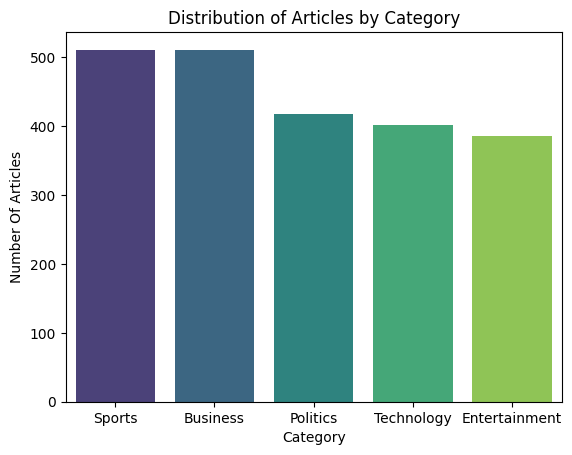

In [7]:
sns.barplot(x = df.Category.value_counts().index,y = df.Category.value_counts().values, palette = 'viridis')
plt.ylabel('Number Of Articles')
plt.title('Distribution of Articles by Category')
plt.show()

In [10]:
df['Article_Length'] = [len(df.Article[i]) for i in range(len(df.Article))]

In [11]:
df

,Category,Article,Article_Length
0,Technology,tv future in the hands of viewers with home th...,4333
1,Business,worldcom boss left books alone former worldc...,1842
2,Sports,tigers wary of farrell gamble leicester say ...,1342
3,Sports,yeading face newcastle in fa cup premiership s...,2176
4,Entertainment,ocean s twelve raids box office ocean s twelve...,1579
...,...,...,...
2220,Business,cars pull down us retail figures us retail sal...,1745
2221,Politics,kilroy unveils immigration policy ex-chatshow ...,955
2222,Entertainment,rem announce new glasgow concert us band rem h...,1648
2223,Politics,how political squabbles snowball it s become c...,4684


In [12]:
avg_len_article = df.groupby('Category')['Article_Length'].mean().sort_values(ascending=False).reset_index()
avg_len_article

,Category,Article_Length
0,Technology,2974.216958
1,Politics,2681.822542
2,Business,1984.617647
3,Entertainment,1926.455959
4,Sports,1894.882583


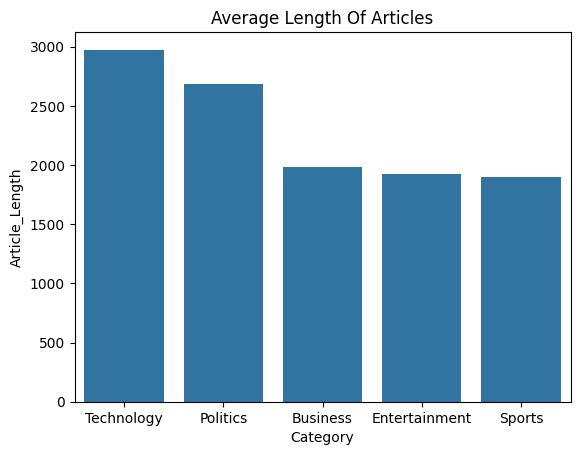

In [13]:
sns.barplot(x = avg_len_article.Category, y=avg_len_article.Article_Length)
plt.title('Average Length Of Articles')
plt.show()

In [14]:
highest_len_article = df.groupby('Category')['Article_Length'].max().sort_values(ascending=False).reset_index()
highest_len_article

,Category,Article_Length
0,Politics,25483
1,Entertainment,19136
2,Technology,16158
3,Sports,9471
4,Business,5406


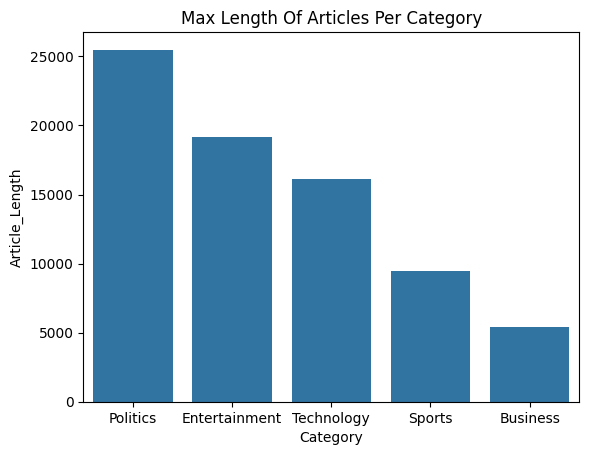

In [15]:
sns.barplot(x = highest_len_article.Category, y=highest_len_article.Article_Length)
plt.title('Max Length Of Articles Per Category')
plt.show()

In [19]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words = stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [24]:
import spacy
nlp = spacy.load('en_core_web_sm')

def pre_process_data(text):
  text = text.lower()
  doc = nlp(text)
  processed_words = []

  for word in doc:
    if word.is_alpha and not word.is_stop:
      processed_words.append(word.lemma_)

  cleaned_text = " ".join(processed_words)

  return cleaned_text

In [26]:
df['Clean_Article'] = df['Article'].apply(pre_process_data)

In [28]:
len(df['Article'][0])

4333

In [27]:
len(df['Clean_Article'][0])

2475

In [23]:
print("Article before processing \n")
print(df['Article'][0])
print("Article after processing \n")
print(df['Clean_Article'][0])

Article before processing 

tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices.  one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and pvr). these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record  store  play  pause and forward wind tv programmes when they want.  essentially  the technology allows for much more personalised tv. they are 

In [ ]:
df.Category.value_counts()

,count
Category,
Sports,511
Business,510
Politics,417
Technology,401
Entertainment,386


In [30]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
cv = CountVectorizer()
word_count_vec = cv.fit_transform(df['Cleaned_Article'])
tfidf = TfidfTransformer()
x = tfidf.fit_transform(word_count_vec)
df_tfidf = pd.DataFrame(x.todense(), columns = tfidf.get_feature_names_out())
display(df_tfidf)

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x32094,x32095,x32096,x32097,x32098,x32099,x32100,x32101,x32102,x32103
0,0.0,0.019502,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.023647,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2220,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2221,0.0,0.089801,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2222,0.0,0.025643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2223,0.0,0.015680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [53]:
x1 = x.toarray()

In [35]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y1 = le.fit_transform(df['Category'])

In [38]:
y1

array([4, 0, 3, ..., 1, 2, 3])

In [85]:
y1[:10]

array([4, 0, 3, 3, 1, 2, 2, 3, 3, 1])

In [86]:
df['Category'][:10]

,Category
0,Technology
1,Business
2,Sports
3,Sports
4,Entertainment
5,Politics
6,Politics
7,Sports
8,Sports
9,Entertainment


In [54]:
x1.shape

(2225, 32104)

In [40]:
y1.shape

(2225,)

In [55]:
from sklearn.model_selection import train_test_split
x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size = 0.25, random_state=42)

In [56]:
print(x1_train.shape,  x1_test.shape)

(1668, 32104) (557, 32104)


In [57]:
print(y1_train.shape, y1_test.shape)

(1668,) (557,)


In [44]:
params = {
          'alpha' : [0.01, 0.1, 1, 10]
          }

In [59]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV

model = MultinomialNB()
clf = GridSearchCV(model, params, scoring = 'f1_weighted', cv=3)
clf.fit(x1_train,y1_train)
res = clf.cv_results_
for i in range(len(res['params'])):
  print(f"Parameters : {res['params'][i]}, Mean Score : {res['mean_test_score'][i]}, Rank : {res['rank_test_score'][i]}")


Parameters : {'alpha': 0.01}, Mean Score : 0.97543119673565, Rank : 1
Parameters : {'alpha': 0.1}, Mean Score : 0.9742905932787586, Rank : 2
Parameters : {'alpha': 1}, Mean Score : 0.9584549335809077, Rank : 3
Parameters : {'alpha': 10}, Mean Score : 0.8268287382754839, Rank : 4


In [62]:
best_alpha = clf.best_params_['alpha']
final_model = MultinomialNB(alpha=best_alpha)
final_model.fit(x1_train, y1_train)

MultinomialNB(alpha=0.01)

              precision    recall  f1-score   support

           0       0.99      0.94      0.97       136
           1       1.00      0.94      0.97        96
           2       0.91      0.99      0.95        98
           3       1.00      1.00      1.00       124
           4       0.96      1.00      0.98       103

    accuracy                           0.97       557
   macro avg       0.97      0.97      0.97       557
weighted avg       0.97      0.97      0.97       557



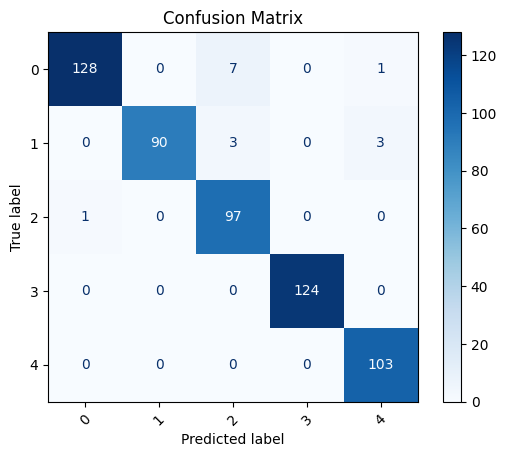

In [69]:
y_pred = final_model.predict(x1_test)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
print(classification_report(y1_test, y_pred))
cm =confusion_matrix(y1_test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = final_model.classes_)
disp.plot(cmap = 'Blues', xticks_rotation = 45)
plt.title('Confusion Matrix')
plt.show()

From Confusion Matrix,

Most of the preidictions are correct,
There are few misclassifications:
1. Business (i.e Class 0) is often misclassified as Politics (i.e Class 2).
2. Entertainment (Class 1) is slightly misclassified in Politics(Class 2) and Technology(Class 4).
3. Politics(Class 2) is often misclassified as Technology(Class 0).

Overall accuracy of the model is 97%

In [73]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [74]:
classifiers = {
    "KNN" : KNeighborsClassifier(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Random Forest" : RandomForestClassifier(),
    }

In [76]:
classifiers.items()

dict_items([('KNN', KNeighborsClassifier()), ('Decision Tree', DecisionTreeClassifier()), ('Random Forest', RandomForestClassifier())])

------KNN------
Accuracy : 0.9353680430879713
Classification Report :
               precision    recall  f1-score   support

           0       0.97      0.86      0.91       136
           1       0.97      0.95      0.96        96
           2       0.85      0.94      0.89        98
           3       0.95      1.00      0.97       124
           4       0.94      0.94      0.94       103

    accuracy                           0.94       557
   macro avg       0.94      0.94      0.94       557
weighted avg       0.94      0.94      0.94       557



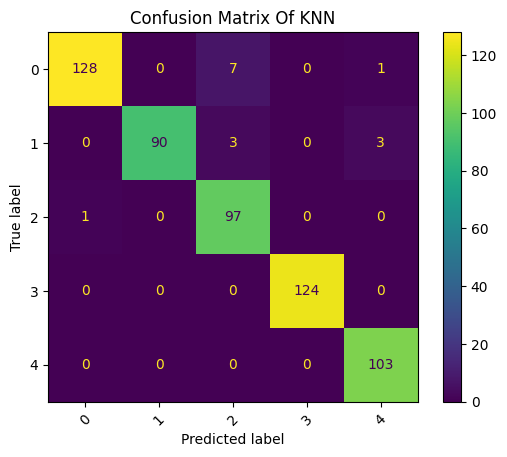

------Decision Tree------
Accuracy : 0.7845601436265709
Classification Report :
               precision    recall  f1-score   support

           0       0.73      0.76      0.74       136
           1       0.81      0.74      0.77        96
           2       0.77      0.78      0.77        98
           3       0.85      0.90      0.87       124
           4       0.78      0.74      0.76       103

    accuracy                           0.78       557
   macro avg       0.79      0.78      0.78       557
weighted avg       0.78      0.78      0.78       557



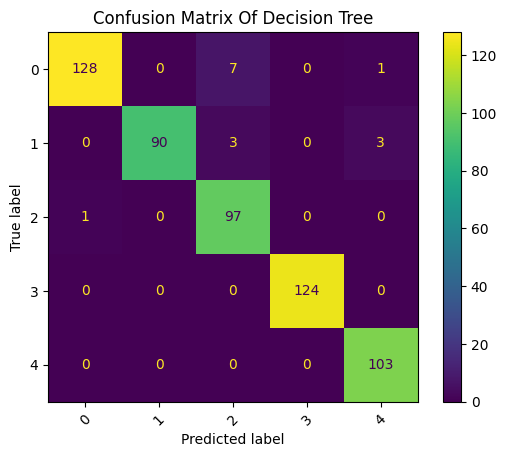

------Random Forest------
Accuracy : 0.940754039497307
Classification Report :
               precision    recall  f1-score   support

           0       0.89      0.96      0.92       136
           1       0.98      0.94      0.96        96
           2       0.94      0.91      0.92        98
           3       0.95      0.99      0.97       124
           4       0.97      0.89      0.93       103

    accuracy                           0.94       557
   macro avg       0.95      0.94      0.94       557
weighted avg       0.94      0.94      0.94       557



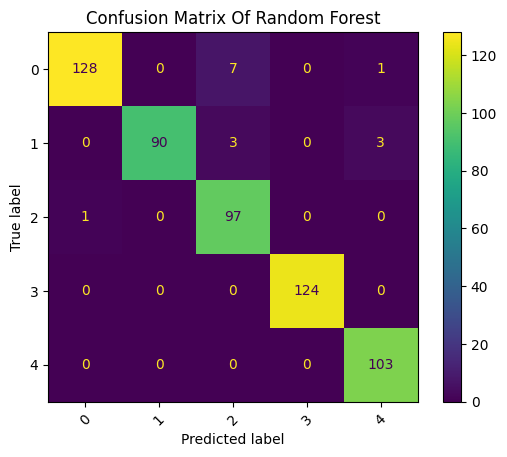

In [84]:
from sklearn.metrics import accuracy_score

for name, model in classifiers.items():
  model.fit(x1_train, y1_train)
  preds = model.predict(x1_test)
  print(f"------{name}------")
  print("Accuracy :", accuracy_score(y1_test, preds))
  print("Classification Report :\n", classification_report(y1_test, preds))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = model.classes_)
  disp.plot(cmap = 'viridis', xticks_rotation=45)
  plt.title(f'Confusion Matrix Of {name}')
  plt.show()

Upon comparision with other classifers:

K-Nearest Neighbors(KNN)

Accuracy - 93%
It gives strong performance, But underperforms slightly compared to NaiveBayes
Similiar misclassifcation between Business and Politics.

Decision Tree

Accuracy - 78.5%
Performs weaker overall.
More prone to overfitting; Bad performance in generalization.

Random Forest

Accuracy - 94.1%
Performs slightly lower compared to Naive Bayes.

Conclusion:

The model is highly effective and aligns with FlipItNews strategic goal of improving user engagement and content discovery through intelligent categorization.
Minor improvements and a better feedback system can further enhance long term performance.